
# Graph Neural Network (GNN) for Quark/Gluon Jet Classification

In [ ]:
import torch

!pip uninstall torch-scatter torch-sparse torch-geometric torch-cluster  --y
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git
!pip install energyflow
!pip install networkx

import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, JumpingKnowledge, global_mean_pool, GATConv
from torch_geometric.data import Data, Batch, DataLoader
from torch_geometric.nn import global_mean_pool

import numpy as np
import energyflow
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy.spatial.transform import Rotation
from sklearn.metrics import roc_auc_score
import networkx as nx

Found existing installation: torch-scatter 2.1.2+pt21cu121
Uninstalling torch-scatter-2.1.2+pt21cu121:
  Successfully uninstalled torch-scatter-2.1.2+pt21cu121
Found existing installation: torch-sparse 0.6.18+pt21cu121
Uninstalling torch-sparse-0.6.18+pt21cu121:
  Successfully uninstalled torch-sparse-0.6.18+pt21cu121
Found existing installation: torch_geometric 2.5.0
Uninstalling torch_geometric-2.5.0:
  Successfully uninstalled torch_geometric-2.5.0
Found existing installation: torch-cluster 1.6.3+pt21cu121
Uninstalling torch-cluster-1.6.3+pt21cu121:
  Successfully uninstalled torch-cluster-1.6.3+pt21cu121
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
  Using cached https://data.pyg.org/whl/torch-2.1.0%2Bcu121/torch_scatter-2.1.2%2Bpt21cu121-cp310-cp310-linux_x86_64.whl (10.8 MB)
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
  Using cached https://data.pyg.org/whl/torch-2.1.0%2Bcu121/torch_sparse-0.6.18%2Bpt21cu121-cp310-cp310-linux_x86_64.whl 

In [ ]:
# Load the dataset
data = energyflow.qg_jets.load(num_data=100000, pad=True, ncol=4, generator='pythia',
                        with_bc=False, cache_dir='~/.energyflow')
X = data[0]
y = data[1]

print(X.shape, y.shape)

URL fetch failure on https://www.dropbox.com/s/fclsl7pukcpobsb/QG_jets.npz?dl=1: None -- Not Found
Failed to download QG_jets.npz from source 'dropbox', trying next source...
(100000, 139, 4) (100000,)


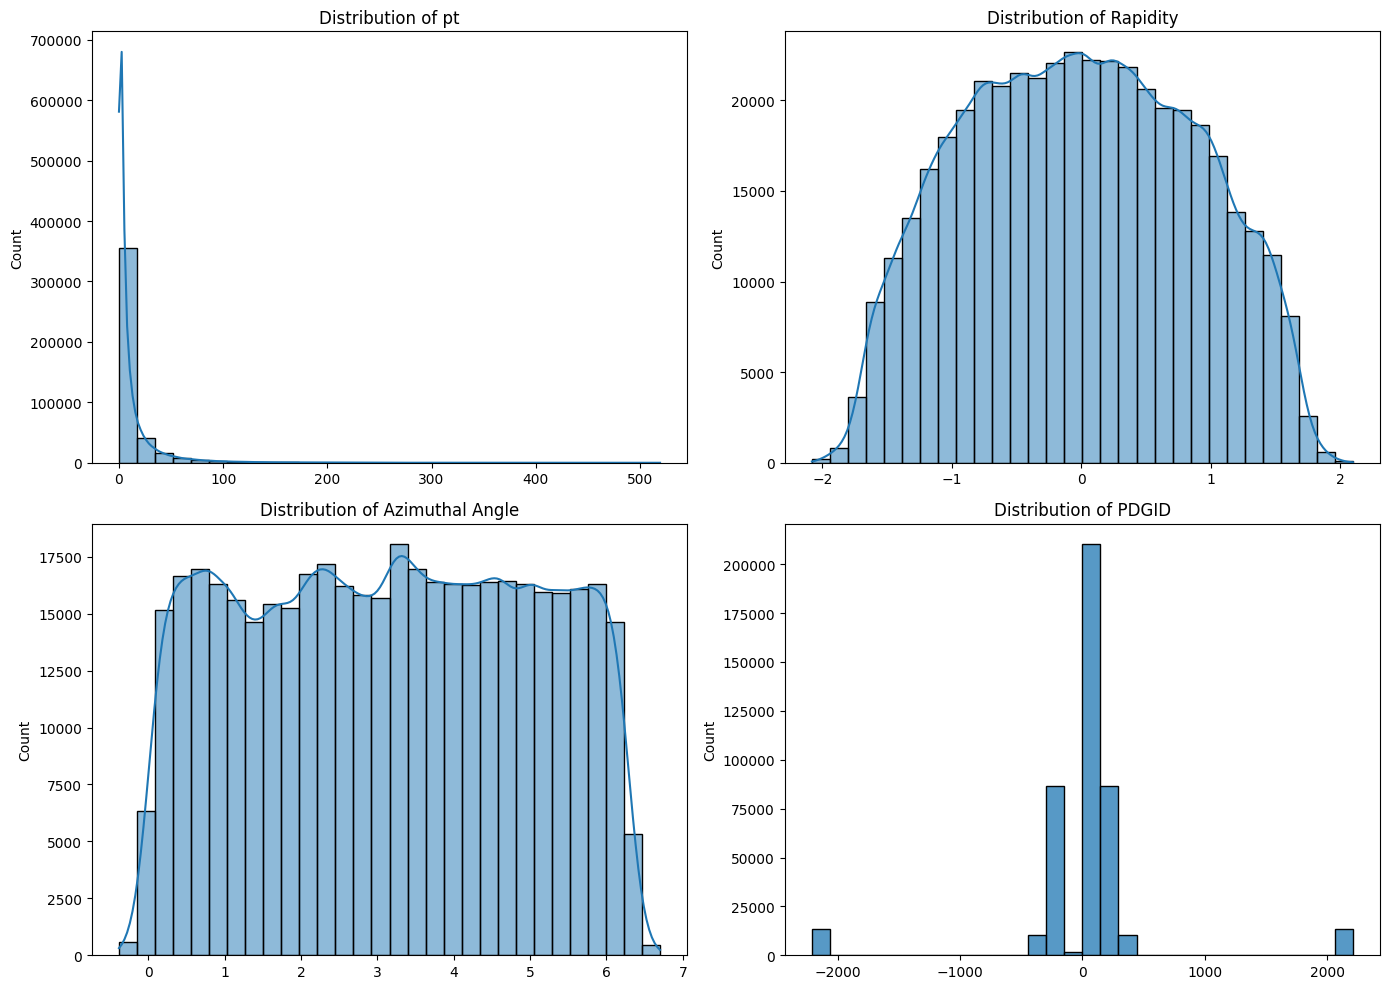

In [ ]:
num_jets = X.shape[0]//10

# Filter out zero padding and concatenate all values from each column across all jets
pt_values = np.concatenate([X[i, :, 0][X[i, :, 0] != 0] for i in range(num_jets)])
rapidity_values = np.concatenate([X[i, :, 1][X[i, :, 1] != 0] for i in range(num_jets)])
azimuthal_angle_values = np.concatenate([X[i, :, 2][X[i, :, 2] != 0] for i in range(num_jets)])
pdgid_values = np.concatenate([X[i, :, 3][X[i, :, 3] != 0] for i in range(num_jets)])

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(pt_values, bins=30, kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Distribution of pt')

sns.histplot(rapidity_values, bins=30, kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Distribution of Rapidity')

sns.histplot(azimuthal_angle_values, bins=30, kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Distribution of Azimuthal Angle')

sns.histplot(pdgid_values, bins=30, kde=False, ax=axs[1, 1])
axs[1, 1].set_title('Distribution of PDGID')

plt.tight_layout()
plt.show()

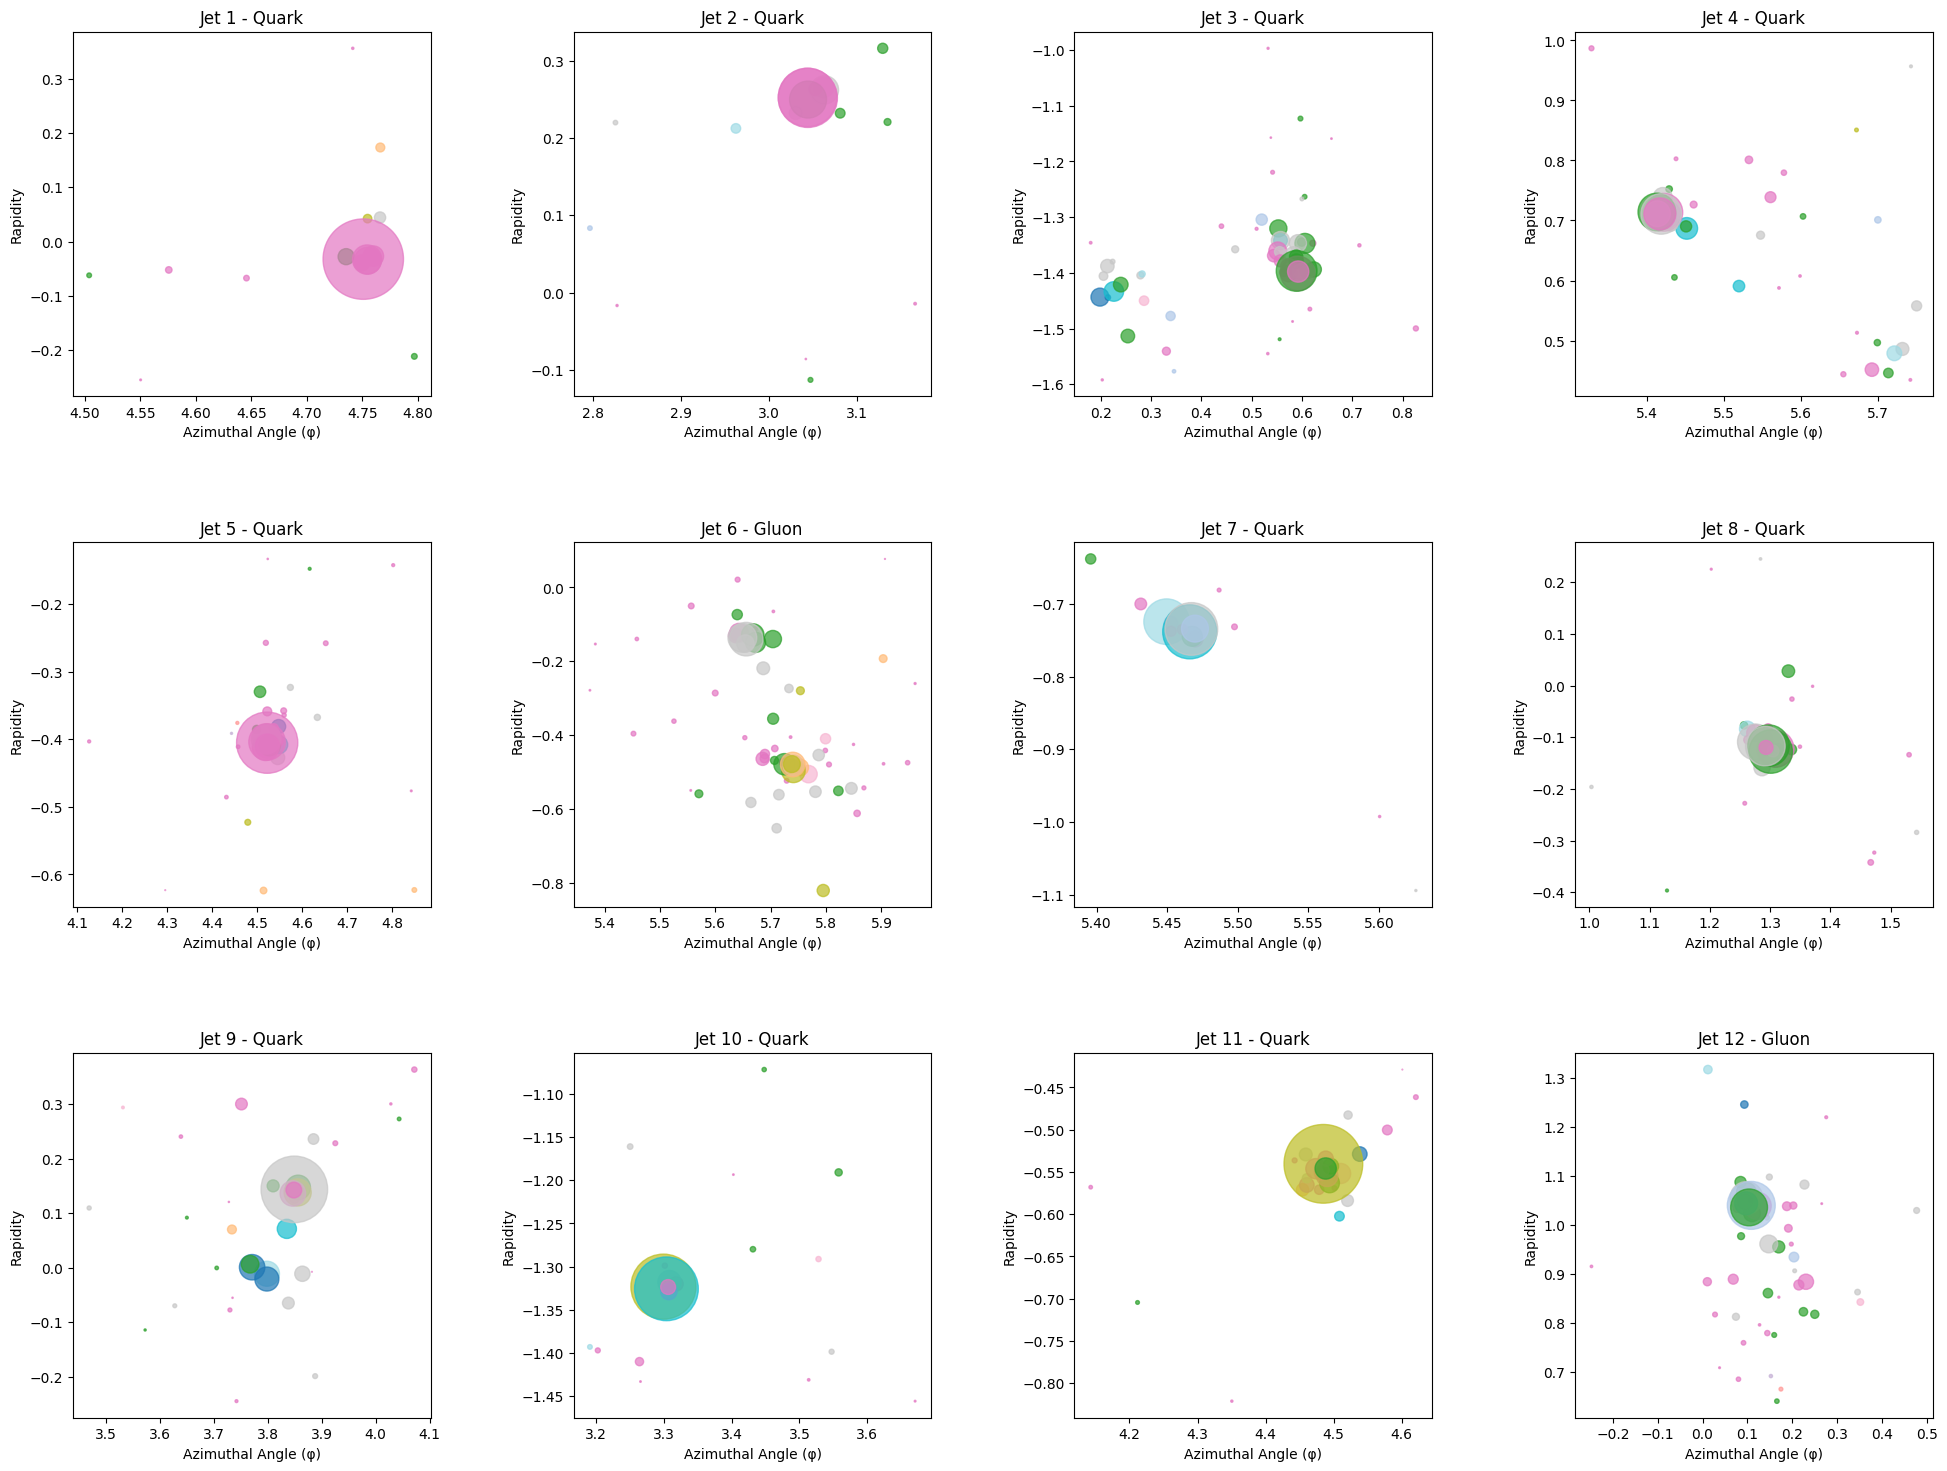

In [ ]:
# List of possible PDG ID values
pdgids = np.array([-2212., -2112., -321.,  -211.,   -13.,   -11.,    11.,    13., 22.,   130.,   211.,   321.,  2112.,  2212.])

# Creates a color map for PDG ID using matplotlib
colors = plt.cm.tab20(np.linspace(0, 1, len(pdgids)))
color_map = {pdgid: color for pdgid, color in zip(pdgids, colors)}

# Initializes a figure with a 3x4 grid of subplots and adjusts spacing
fig, axs = plt.subplots(3, 4, figsize=(24, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

# Iterates through the first 12 jets in the dataset
for i in range(12):
    row = i // 4
    col = i % 4
    ax = axs[row, col]

    # Filter out the zero padding from the jet data to focus on actual particle data
    X_i_filtered = X[i][np.any(X[i] != 0, axis=1)]

    # Extracts the pt, rapidity, azimuthal angle, and PDG ID for each particle in the jet
    pt = X_i_filtered[:, 0]
    rapidity = X_i_filtered[:, 1]
    azimuth = X_i_filtered[:, 2]
    pdgid = X_i_filtered[:, 3]

    # Maps each particle's PDG ID to a specific color using the previously defined color map
    colors = np.array([color_map[id] for id in pdgid])

    # Creates a scatter plot for the current jet with azimuthal angle on the x-axis and rapidity on the y-axis
    ax.scatter(azimuth, rapidity, s=pt*10, c=colors, alpha=0.7)
    ax.set_xlabel('Azimuthal Angle (φ)')
    ax.set_ylabel('Rapidity')
    ax.set_title(f'Jet {i+1} - {"Quark" if y[i] == 1 else "Gluon"}')  # Sets the title indicating the jet number and type

plt.show()  # Displays the figure with all subplots

### Each jet is represented as a complete graph where nodes correspond to particles and edges represent the spatial relationships between particles. Features of nodes include the particle's traverse momentum (pT ) and a one-hot encoded vector of the pdgid. Edges were weighted by the angular distance between particles, considering the azimuthal angle (φ) and the rapidity (𝛈) converted to angle by the formula 𝜃 = 2 𝑎𝑟𝑐𝑡𝑎𝑛( exp (−η)). Then edges were scaled in order to make edges connecting adjacent particles weighting 1 and opposite direction particles edges weighting 0.

In [ ]:
def delta_phi(phi1, phi2):
    # Calculate angular difference
    dphi = np.abs(phi1 - phi2)
    dphi = np.where(dphi > np.pi, 2*np.pi - dphi, dphi)
    return dphi

# Possible PDG ID
possible_pdgids = np.array([-2212., -2112., -321., -211., -13., -11., 11., 13., 22., 130., 211., 321., 2112., 2212.])

def one_hot_encode(pdgids, possible_pdgids):
    encoded = np.zeros((len(pdgids), len(possible_pdgids)))

    for i, pdgid in enumerate(pdgids):
        index = np.where(possible_pdgids == pdgid)[0]
        if index.size > 0:
            encoded[i, index] = 1
    return encoded

def create_graph(jet, possible_pdgids = possible_pdgids):
    # Remove zero-padded particles
    jet = jet[~np.all(jet == 0, axis=1)]

    # Create a fully connected graph
    graph = nx.Graph()

    # Add nodes with pt and one-hot encoded pdgid as features
    pt = jet[:, 0]
    pdgid_one_hot = one_hot_encode(jet[:, 3], possible_pdgids)
    node_features = np.column_stack((pt, pdgid_one_hot))
    for i, features in enumerate(node_features):
        graph.add_node(i, features=features)

    # Add weighted edges based on angular distance
    for i, particle_i in enumerate(jet):
        for j, particle_j in enumerate(jet[i+1:], start=i+1):
            phi_i, phi_j = particle_i[2], particle_j[2]
            rapidity_i, rapidity_j = particle_i[1], particle_j[1]

            # Convert rapidity to theta
            theta_i = 2 * np.arctan(np.exp(-rapidity_i))
            theta_j = 2 * np.arctan(np.exp(-rapidity_j))

            # Calculate delta_phi considering cyclic nature
            dphi = delta_phi(phi_i, phi_j)

            # Calculate spatial distance using delta_theta and delta_phi
            spatial_distance = distance.euclidean([theta_i, dphi], [theta_j, 0])
            scaled_distance = (np.pi - spatial_distance) / np.pi
            graph.add_edge(i, j, weight=scaled_distance)

    return graph

In [ ]:
graph = create_graph(X[0], possible_pdgids)

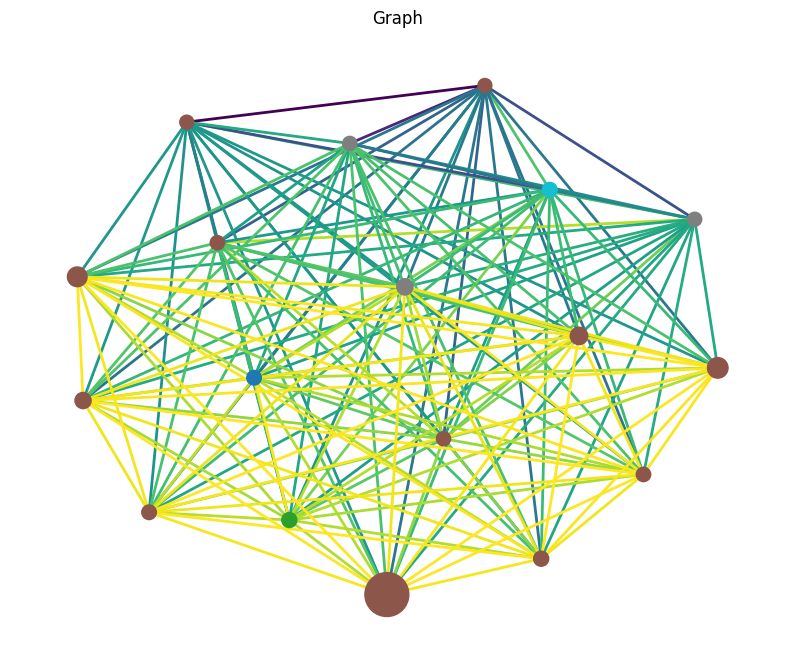

In [ ]:
def plot_graph(graph):
    # Extract node features
    node_features = np.array([data['features'] for _, data in graph.nodes(data=True)])
    pt = node_features[:, 0]
    pdgid_one_hot = node_features[:, 1:]

    # Set up color map for pdgids
    unique_pdgids = np.unique(pdgid_one_hot, axis=0)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_pdgids)))
    pdgid_colors = {tuple(pdgid): color for pdgid, color in zip(unique_pdgids, colors)}

    # Set up node sizing based on pt
    node_sizes = 900 * (pt / pt.max()) + 100  # Scale node sizes between 100 and 1000

    # Draw the graph
    pos = nx.spring_layout(graph)
    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw(graph, pos, node_color=[pdgid_colors[tuple(pdgid)] for pdgid in pdgid_one_hot], node_size=node_sizes,
            edge_color=[edge[2]['weight'] for edge in graph.edges(data=True)], width=2, with_labels=False, ax=ax)
    ax.set_title('Graph')
    plt.show()

# Plot the first graph
plot_graph(graph)

In [ ]:
def nx_to_pyg(graph, label):
    # Extract the edge list from the NetworkX graph and convert it to a PyTorch tensor.
    # 'edge_list' contains tuples representing connections between nodes.
    edge_list = list(graph.edges(data=False))
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    # Transform the node features into a PyTorch tensor.
    features = np.array([graph.nodes[node]['features'] for node in graph.nodes()])
    x = torch.tensor(features, dtype=torch.float)

    # Convert the label into a PyTorch tensor.
    y = torch.tensor([label], dtype=torch.long)

    # Create a PyTorch Geometric Data object.
    data = Data(x=x, edge_index=edge_index, y=y)

    return data

pyg_graphs = [nx_to_pyg(create_graph(X[i], possible_pdgids), y[i]) for i in range(len(X))]

In [ ]:
# train and test dim
train_size = int(0.8 * len(pyg_graphs))
test_size = len(pyg_graphs) - train_size

# Divide data
train_dataset, test_dataset = random_split(pyg_graphs, [train_size, test_size])

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


### Graph Convolutional Network, included two GCNConv layers for feature extraction, followed by global mean pooling to aggregate graph features into a single representation for classification. This model was designed to leverage the spatial structure of the jets for effective feature extraction and classification.

In [ ]:
class CGN(nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(CGN, self).__init__()
        # Convolution layers with increased size
        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, 128)
        #  perceptron layers
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        # Process through the convolution layers with ReLU activation
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        # Apply global mean pooling to aggregate features
        x = global_mean_pool(x, batch)
        # Pass the pooled graph representation large fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Initialize the model
model_cgn = CGN(num_node_features=15, num_classes=2)

In [ ]:
optimizer = torch.optim.Adam(model_cgn.parameters(), lr=0.005)

def train():
    model_cgn.train()
    for data in train_loader:
        optimizer.zero_grad()
        out = model_cgn(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()

def test(loader):
    model_cgn.eval()
    correct = 0
    all_preds = []
    all_labels = []
    for data in loader:
        out = model_cgn(data)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        # Store probability scores and true labels for AUC calculation
        prob_scores = out[:, 1].detach().cpu().numpy()
        labels = data.y.cpu().numpy()
        all_preds.extend(prob_scores)
        all_labels.extend(labels)

    accuracy = correct / len(loader.dataset)
    auc_score = roc_auc_score(all_labels, all_preds)
    return accuracy, auc_score

for epoch in range(1, 4):
    loss = train()
    train_acc, train_auc = test(train_loader)
    test_acc, test_auc = test(test_loader)
    print(f'Epoch: {epoch}, Loss: {loss}, Train Acc: {train_acc}, Train AUC: {train_auc}, Test Acc: {test_acc}, Test AUC: {test_auc}')

Epoch: 1, Loss: None, Train Acc: 0.77065, Train AUC: 0.846737317583617, Test Acc: 0.7721, Test AUC: 0.8507940354901082
Epoch: 2, Loss: None, Train Acc: 0.7675875, Train AUC: 0.8436313744258521, Test Acc: 0.76855, Test AUC: 0.8475981480005812
Epoch: 3, Loss: None, Train Acc: 0.7677125, Train AUC: 0.8460429823480344, Test Acc: 0.7683, Test AUC: 0.8495598749167136


### Graph Attention Network, includes GATConv layers to learn the importance of each node's neighbors. This approach allowed the model to focus on the most relevant parts of the graph for classification

In [ ]:
class GATNet(nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GATNet, self).__init__()
        # First GAT layer with multi-head attention
        self.conv1 = GATConv(num_node_features, 8, heads=8, dropout=0.1)
        # Second GAT layer to refine the features, reducing the heads to consolidate information
        self.conv2 = GATConv(8*8, 32, heads=1, concat=True, dropout=0.1)
        # An additional linear layer for further feature transformation
        self.lin = nn.Linear(32, 32)
        # Final classification layer
        self.fc = nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Input dropout for regularization
        x = F.dropout(x, p=0.1, training=self.training)
        # Apply the first GAT convolutional layer with ELU activation
        x = F.elu(self.conv1(x, edge_index))
        # Dropout applied to the output of the first GAT layer
        x = F.dropout(x, p=0.1, training=self.training)
        # Apply the second GAT convolutional layer
        x = self.conv2(x, edge_index)

        # Apply global mean pooling to aggregate node features into graph features
        x = global_mean_pool(x, batch)

        # Additional linear layer with ReLU activation for non-linear transformation
        x = F.relu(self.lin(x))
        # Final classification layer with log softmax activation for prediction
        x = self.fc(x)

        return F.log_softmax(x, dim=1)


model_gat = GATNet(num_node_features=15, num_classes=2)

In [ ]:
optimizer = torch.optim.Adam(model_gat.parameters(), lr=0.005)

def train():
    model_gat.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model_gat(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def test(loader):
    model_gat.eval()
    correct = 0
    all_preds = []
    all_labels = []
    for data in loader:
        out = model_gat(data)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        # Store probability scores and true labels for AUC calculation
        prob_scores = out[:, 1].detach().cpu().numpy()
        labels = data.y.cpu().numpy()
        all_preds.extend(prob_scores)
        all_labels.extend(labels)

    accuracy = correct / len(loader.dataset)
    auc_score = roc_auc_score(all_labels, all_preds)
    return accuracy, auc_score

for epoch in range(1, 4):
    loss = train()
    train_acc, train_auc = test(train_loader)
    test_acc, test_auc = test(test_loader)
    print(f'Epoch: {epoch}, Loss: {loss}, Train Acc: {train_acc}, Train AUC: {train_auc}, Test Acc: {test_acc}, Test AUC: {test_auc}')

Epoch: 1, Loss: 0.6117907468318939, Train Acc: 0.70215, Train AUC: 0.792524613006627, Test Acc: 0.7001, Test AUC: 0.7960819235841623
Epoch: 2, Loss: 0.5632164181947709, Train Acc: 0.73215, Train AUC: 0.8021706671935293, Test Acc: 0.73425, Test AUC: 0.8065578498398915
Epoch: 3, Loss: 0.5625792155265809, Train Acc: 0.735425, Train AUC: 0.8074119353737672, Test Acc: 0.7369, Test AUC: 0.8107524696712514
